In [4]:
library(org.Hs.eg.db)
library(AnnotationDbi)
library(ggplot2)
library(lumi)
library(missMethyl)
library(ggridges)

Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Loading required package: IRanges

Loading required package: S4Vectors

In [5]:
missmethyl = readRDS("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Table 3 KEGG enrich missMethyl_v1.28.0/missmethyl_kegg.rds")

In [6]:
length(missmethyl$idList)

[1] 241

In [8]:
#cobre_beta = readRDS("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Figure 1 Differential analysis/cobre_beta.rds")
cobre_beta = readRDS("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Figure 1 Differential analysis/cobre_beta_nocrosshyb.rds")
cobre_pd = readRDS("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Figure 1 Differential analysis/cobre_pd.rds")

In [7]:
anno = readRDS("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Figure 1 Differential analysis/anno_450k.rds")

In [9]:
length(unique(anno$UCSC_RefGene_Name))

[1] 20619

In [10]:
entrez_ids <- mapIds(org.Hs.eg.db, 
                     keys = unique(anno$UCSC_RefGene_Name), 
                     column = "ENTREZID", 
                     keytype = "SYMBOL", 
                     multiVals = "first")

'select()' returned 1:many mapping between keys and columns



In [11]:
gene_2_enz = as.data.frame(entrez_ids)

In [12]:
gene_2_enz$gene = names(entrez_ids)

In [13]:
getwd()

[1] "/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Table 3 KEGG enrich missMethyl_v1.28.0"

In [12]:
save(anno,gene_2_enz,file='annotation_entrez.rdata')

In [3]:
load('annotation_entrez.rdata',verbose=TRUE)

Loading objects:
  anno
  gene_2_enz


In [10]:
CpG_anno_enz = merge(anno,gene_2_enz,by.x='UCSC_RefGene_Name',by.y='gene')

In [11]:
CpG_anno_enz

DataFrame with 364645 rows and 4 columns
       UCSC_RefGene_Name        Name UCSC_RefGene_Group  entrez_ids
             <character> <character>        <character> <character>
1                   A1BG  cg11001216               Body           1
2                   A1BG  cg14222245               Body           1
3                   A1BG  cg03123289               Body           1
4                   A1BG  cg22286978               Body           1
5                   A1BG  cg10734734               Body           1
...                  ...         ...                ...         ...
364641              ZZZ3  cg04127303              5'UTR       26009
364642              ZZZ3  cg24358066            TSS1500       26009
364643              ZZZ3  cg17033546              5'UTR       26009
364644              ZZZ3  cg01485247             TSS200       26009
364645              ZZZ3  cg05776075            TSS1500       26009

In [20]:
pathway_cpg_mapping = as.data.frame(c())
for(i in 1:length(missmethyl$idList)){
    path = missmethyl$idList[i]
    CpG_anno_enz_tss = CpG_anno_enz[CpG_anno_enz$UCSC_RefGene_Group%in%c('TSS200','TSS1500'),]
    all_cpg = as.data.frame(CpG_anno_enz[CpG_anno_enz$entrez_ids%in%path[[1]],])
    #print(all_cpg$Name)
    tss_cpg = as.data.frame(CpG_anno_enz_tss[CpG_anno_enz_tss$entrez_ids%in%path[[1]],])
    #print(tss_cpg$Name)
    res = c(names(path),
            missmethyl$idTable[missmethyl$idTable$PathwayID==names(path),'Description'],
            length(path[[1]]),
            dim(all_cpg)[1],
            dim(tss_cpg)[1],
           paste(unique(all_cpg$Name),collapse = ','),
           paste(unique(tss_cpg$Name),collapse = ','))
    pathway_cpg_mapping = rbind(pathway_cpg_mapping,res)
}
colnames(pathway_cpg_mapping) = c('KEGGID','Pathway','N_gene','N_CpG','N_TSS_CpG','All_CpG','TSS_CpG')
rownames(pathway_cpg_mapping) = pathway_cpg_mapping$KEGGID
#pathway_cpg_mapping
write.csv(pathway_cpg_mapping,'pathway_cpg_mapping_cpglist.csv',quote=TRUE)

In [21]:
pathway_cpg_mapping[1:5,]

KEGGID        Pathway                                  N_gene
path:hsa00010 path:hsa00010 Glycolysis / Gluconeogenesis             67    
path:hsa00020 path:hsa00020 Citrate cycle (TCA cycle)                30    
path:hsa00030 path:hsa00030 Pentose phosphate pathway                30    
path:hsa00040 path:hsa00040 Pentose and glucuronate interconversions 35    
path:hsa00051 path:hsa00051 Fructose and mannose metabolism          33    
              N_CpG N_TSS_CpG
path:hsa00010 1034  373      
path:hsa00020 515   202      
path:hsa00030 502   158      
path:hsa00040 384   157      
path:hsa00051 700   185      
              All_CpG                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [35]:
pathway_cpg_mapping = as.data.frame(c())
for(i in 1:length(missmethyl$idList)){
    path = missmethyl$idList[i]
    CpG_anno_enz_tss = CpG_anno_enz[CpG_anno_enz$UCSC_RefGene_Group%in%c('TSS200','TSS1500'),]
    all_cpg = CpG_anno_enz[CpG_anno_enz$entrez_ids%in%path[[1]],]
    tss_cpg = CpG_anno_enz_tss[CpG_anno_enz_tss$entrez_ids%in%path[[1]],]
    res = c(names(path),missmethyl$idTable[missmethyl$idTable$PathwayID==names(path),'Description'],length(path[[1]]),dim(all_cpg)[1],dim(tss_cpg)[1])
    pathway_cpg_mapping = rbind(pathway_cpg_mapping,res)
}
colnames(pathway_cpg_mapping) = c('KEGGID','Pathway','N_gene','N_CpG','N_TSS_CpG')
rownames(pathway_cpg_mapping) = pathway_cpg_mapping$KEGGID
write.csv(pathway_cpg_mapping,'pathway_cpg_mapping.csv',quote=TRUE)

In [1]:
pathway_cpg_mapping = read.csv('pathway_cpg_mapping.csv')
pathway_cpg_mapping[1:5,]

,X,KEGGID,Pathway,N_gene,N_CpG,N_TSS_CpG
,<chr>,<chr>,<chr>,<int>,<int>,<int>
1,path:hsa00010,path:hsa00010,Glycolysis / Gluconeogenesis,67,1034,373
2,path:hsa00020,path:hsa00020,Citrate cycle (TCA cycle),30,515,202
3,path:hsa00030,path:hsa00030,Pentose phosphate pathway,30,502,158
4,path:hsa00040,path:hsa00040,Pentose and glucuronate interconversions,35,384,157
5,path:hsa00051,path:hsa00051,Fructose and mannose metabolism,33,700,185


In [29]:
missmethyl$idTable[missmethyl$idTable$PathwayID=='path:hsa03008',]

,PathwayID,Description
,<chr>,<chr>
99,path:hsa03008,Ribosome biogenesis in eukaryotes


In [44]:
strsplit(hyper_kegg$SigGenesInSet[1],',')[[1]]

[1] "DLAT"    "ALDH9A1" "PFKL"    "PGM2"    "ACSS1"   "G6PC3"

In [45]:
hyper_kegg = read.csv("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Table 3 KEGG enrich missMethyl_v1.28.0/gst.kegg.hyper.modified_removecrosshyb.csv",row.names=1)
pathway_cpg_mapping_pval = merge(pathway_cpg_mapping,hyper_kegg[,c('N','DE','P.DE','FDR','SigGenesInSet')],by=0)
rownames(pathway_cpg_mapping_pval) = pathway_cpg_mapping_pval[,1]
pathway_cpg_mapping_pval[pathway_cpg_mapping_pval$FDR<0.05,]

,Row.names,KEGGID,Pathway,N_gene,N_CpG,N_TSS_CpG,N,DE,P.DE,FDR,SigGenesInSet
,<I<chr>>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>
path:hsa03008,path:hsa03008,path:hsa03008,Ribosome biogenesis in eukaryotes,109,1001,421,75,25,3.918461e-04,0.023608726,"NXF1,RPP30,RPP38,POP4,RPP25L,CSNK2A1,CSNK2B,AFG2A,DROSHA,NXT1,GNL2,FBLL1,SNU13,FCF1,SBDS,POP5,HEATR1,NAT10,IMP3,LSG1,NOP10,REXO1,RAN,XPO1,IMP4"
path:hsa03010,path:hsa03010,path:hsa03010,Ribosome,158,1620,827,131,39,1.803034e-04,0.021515098,"MRPL10,FAU,MRPL13,RPSA,MRPS16,RPS27L,MRPL2,MRPL4,RSL24D1,MRPL30,RPL3,RPL7,RPL11,RPL12,RPL18A,RPL21,RPL22,RPL30,RPL34,RPL35A,RPL37A,RPLP2,MRPS12,RPS8,RPS9,RPS12,RPS15,RPS18,RPS25,RPS28,MRPL17,MRPS11,MRPS9,MRPL34,MRPL1,UBA52,RPL14,RPL23,MRPL19"
path:hsa03013,path:hsa03013,path:hsa03013,Nucleocytoplasmic transport,108,1498,640,107,33,2.678228e-04,0.021515098,"SRRM1,SAP18,NXF1,NUP42,NUP35,CSE1L,CASC3,ACIN1,NUP210,NUP160,NUP188,AHCTF1,NXT1,KPNA1,KPNB1,KPNA2,KPNA3,KPNA4,SUMO4,PHAX,MAGOHB,IPO9,NUP107,RAN,RANGAP1,SENP2,XPO4,XPO1,PYM1,NUP210L,POM121L2,IPO13,NUP93"
path:hsa04110,path:hsa04110,path:hsa04110,Cell cycle,126,3105,985,126,42,5.079074e-06,0.001224057,"CDK2,CDKN1A,CDKN1B,STAG1,CDKN1C,CDKN2A,CDKN2C,CDKN2D,ANAPC10,DBF4,CHEK1,GADD45A,E2F2,E2F3,E2F4,ORC3,ABL1,ANAPC13,ANAPC4,HDAC1,SMAD2,MCM5,MCM6,ATM,ORC1,PCNA,ANAPC7,ANAPC11,RAD21,RBL2,ANAPC1,SKP2,TGFB2,TTK,YWHAG,CUL1,CDC14A,CCNA1,SMC3,CDK1,CDC25A,CDC25C"
path:hsa04150,path:hsa04150,path:hsa04150,mTOR signaling pathway,156,4172,1049,155,42,9.277182e-04,0.044716016,"LAMTOR5,CHUK,EIF4EBP1,FLCN,AKT1,RNF152,MTOR,FZD2,GRB2,IKBKB,INS,RHOA,LAMTOR4,ATP6V1A,ATP6V1C1,ATP6V1E1,ATP6V1G2,DDIT4,STRADB,PRKCG,MAP2K1,RPTOR,RAF1,RHEB,RPS6KA2,DEPTOR,SKP2,SLC3A2,SOS2,BRAF,WNT3,WNT5A,WNT2B,WNT5B,NPRL3,CAB39L,PIK3R3,WNT3A,STRADA,EIF4E2,LPIN2,DEPDC5"


In [112]:
dim(cobre_beta)[1]

[1] 408773

In [60]:
sig_cpg = c()
for(i in 1:dim(pathway_cpg_mapping_pval)[1]){
    id = rownames(pathway_cpg_mapping_pval)[i]
    siggene = strsplit(hyper_kegg[id,]$SigGenesInSet,',')[[1]]
    cpg_names = rownames(limma_res[limma_res$UCSC_RefGene_Name%in%siggene,])
    sig_cpg = c(sig_cpg,length(cpg_names))
}
pathway_cpg_mapping_pval$sig_cpg = sig_cpg

In [ ]:
strsplit(hyper_kegg$SigGenesInSet[1],',')[[1]]%in%limma_res

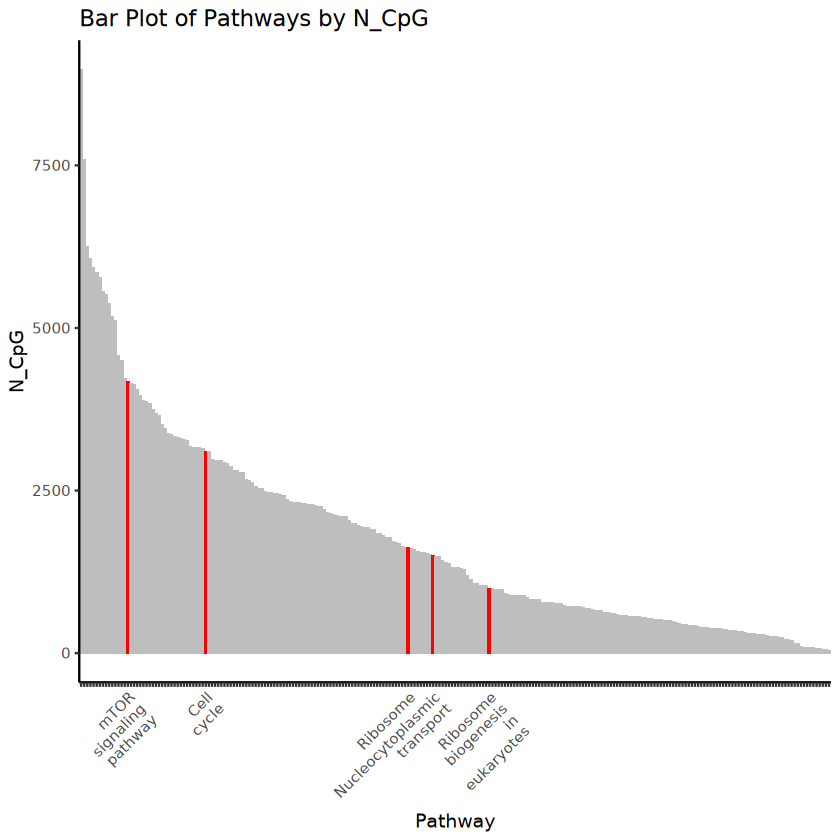

In [105]:
library(ggplot2)
pathway_cpg_mapping_pval$Highlight <- ifelse(pathway_cpg_mapping_pval$FDR < 0.05, "red", "grey")
pathway_cpg_mapping_pval$Label <- ifelse(pathway_cpg_mapping_pval$FDR < 0.05, 
                                         gsub(" ", "\n", pathway_cpg_mapping_pval$Pathway), 
                                         "")

pathway_cpg_mapping_pval <- pathway_cpg_mapping_pval[order(pathway_cpg_mapping_pval$N_CpG, decreasing = TRUE), ]
pathway_cpg_mapping_pval$N_CpG <- as.numeric(pathway_cpg_mapping_pval$N_CpG)
pathway_cpg_mapping_pval$N_gene <- as.numeric(pathway_cpg_mapping_pval$N_gene)
pathway_cpg_mapping_pval$N_TSS_CpG <- as.numeric(pathway_cpg_mapping_pval$N_TSS_CpG)

ggplot(pathway_cpg_mapping_pval, aes(x = reorder(Pathway, -N_CpG), y = N_CpG, fill = Highlight)) +
  geom_bar(stat = "identity") +
  scale_fill_identity() +
  labs(
    title = "Bar Plot of Pathways by N_CpG",
    x = "Pathway",
    y = "N_CpG"
  ) +theme_classic() +
theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )+
scale_x_discrete(labels = pathway_cpg_mapping_pval$Label)


In [108]:
png('pathway_cpg_mapping_size.png',width=6,height=6,res=300,unit='in')
ggplot(pathway_cpg_mapping_pval, aes(x = reorder(Pathway, -N_CpG), y = N_CpG, fill = Highlight)) +
  geom_bar(stat = "identity") +
  scale_fill_identity() +
  labs(
    title = "Bar Plot of Pathways by N_CpG",
    x = "Pathway",
    y = "N_CpG"
  ) +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )+
scale_x_discrete(labels = pathway_cpg_mapping_pval$Label)
dev.off()

png 
  2

In [41]:
limma_res = readRDS("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Figure 1 Differential analysis/cobre_limma_sig_nocroshyb_withanno_12517.rds")
dim(limma_res[limma_res$Type=='Hyper'&limma_res$UCSC_RefGene_Group%in%c('TSS200','TSS1500'),])

[1] 3573   11

In [65]:
pathway_cpg_mapping_pval$N_gene = as.numeric(pathway_cpg_mapping_pval$N_gene)
pathway_cpg_mapping_pval$N_CpG = as.numeric(pathway_cpg_mapping_pval$N_CpG)
pathway_cpg_mapping_pval$N_TSS_CpG = as.numeric(pathway_cpg_mapping_pval$N_TSS_CpG)
pathway_cpg_mapping_pval[pathway_cpg_mapping_pval$FDR<0.05,]
sum(pathway_cpg_mapping_pval$N_CpG)

,Row.names,KEGGID,Pathway,N_gene,N_CpG,N_TSS_CpG,N,DE,P.DE,FDR,SigGenesInSet,sig_cpg
,<I<chr>>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>,<int>
path:hsa03008,path:hsa03008,path:hsa03008,Ribosome biogenesis in eukaryotes,109,1001,421,75,25,3.918461e-04,0.023608726,"NXF1,RPP30,RPP38,POP4,RPP25L,CSNK2A1,CSNK2B,AFG2A,DROSHA,NXT1,GNL2,FBLL1,SNU13,FCF1,SBDS,POP5,HEATR1,NAT10,IMP3,LSG1,NOP10,REXO1,RAN,XPO1,IMP4",38
path:hsa03010,path:hsa03010,path:hsa03010,Ribosome,158,1620,827,131,39,1.803034e-04,0.021515098,"MRPL10,FAU,MRPL13,RPSA,MRPS16,RPS27L,MRPL2,MRPL4,RSL24D1,MRPL30,RPL3,RPL7,RPL11,RPL12,RPL18A,RPL21,RPL22,RPL30,RPL34,RPL35A,RPL37A,RPLP2,MRPS12,RPS8,RPS9,RPS12,RPS15,RPS18,RPS25,RPS28,MRPL17,MRPS11,MRPS9,MRPL34,MRPL1,UBA52,RPL14,RPL23,MRPL19",46
path:hsa03013,path:hsa03013,path:hsa03013,Nucleocytoplasmic transport,108,1498,640,107,33,2.678228e-04,0.021515098,"SRRM1,SAP18,NXF1,NUP42,NUP35,CSE1L,CASC3,ACIN1,NUP210,NUP160,NUP188,AHCTF1,NXT1,KPNA1,KPNB1,KPNA2,KPNA3,KPNA4,SUMO4,PHAX,MAGOHB,IPO9,NUP107,RAN,RANGAP1,SENP2,XPO4,XPO1,PYM1,NUP210L,POM121L2,IPO13,NUP93",47
path:hsa04110,path:hsa04110,path:hsa04110,Cell cycle,126,3105,985,126,42,5.079074e-06,0.001224057,"CDK2,CDKN1A,CDKN1B,STAG1,CDKN1C,CDKN2A,CDKN2C,CDKN2D,ANAPC10,DBF4,CHEK1,GADD45A,E2F2,E2F3,E2F4,ORC3,ABL1,ANAPC13,ANAPC4,HDAC1,SMAD2,MCM5,MCM6,ATM,ORC1,PCNA,ANAPC7,ANAPC11,RAD21,RBL2,ANAPC1,SKP2,TGFB2,TTK,YWHAG,CUL1,CDC14A,CCNA1,SMC3,CDK1,CDC25A,CDC25C",63
path:hsa04150,path:hsa04150,path:hsa04150,mTOR signaling pathway,156,4172,1049,155,42,9.277182e-04,0.044716016,"LAMTOR5,CHUK,EIF4EBP1,FLCN,AKT1,RNF152,MTOR,FZD2,GRB2,IKBKB,INS,RHOA,LAMTOR4,ATP6V1A,ATP6V1C1,ATP6V1E1,ATP6V1G2,DDIT4,STRADB,PRKCG,MAP2K1,RPTOR,RAF1,RHEB,RPS6KA2,DEPTOR,SKP2,SLC3A2,SOS2,BRAF,WNT3,WNT5A,WNT2B,WNT5B,NPRL3,CAB39L,PIK3R3,WNT3A,STRADA,EIF4E2,LPIN2,DEPDC5",89


[1] 417702

In [68]:
pathway_cpg_mapping_pval[pathway_cpg_mapping_pval$FDR<0.05,c(1,2,3,4,5,6,7,8,12)]

,Row.names,KEGGID,Pathway,N_gene,N_CpG,N_TSS_CpG,N,DE,sig_cpg
,<I<chr>>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
path:hsa03008,path:hsa03008,path:hsa03008,Ribosome biogenesis in eukaryotes,109,1001,421,75,25,38
path:hsa03010,path:hsa03010,path:hsa03010,Ribosome,158,1620,827,131,39,46
path:hsa03013,path:hsa03013,path:hsa03013,Nucleocytoplasmic transport,108,1498,640,107,33,47
path:hsa04110,path:hsa04110,path:hsa04110,Cell cycle,126,3105,985,126,42,63
path:hsa04150,path:hsa04150,path:hsa04150,mTOR signaling pathway,156,4172,1049,155,42,89


In [92]:
pathway_cpg_mapping_pval[pathway_cpg_mapping_pval$FDR<0.05,c(3,4,5,6,8,12,10,16,17)]

,Pathway,N_gene,N_CpG,N_TSS_CpG,DE,sig_cpg,FDR,hypergeo_p_value,hypergeo_FDR
,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
path:hsa03008,Ribosome biogenesis in eukaryotes,109,1001,421,25,38,0.023608726,3.497122e-26,3.121506e-25
path:hsa03010,Ribosome,158,1620,827,39,46,0.021515098,1.668410e-22,1.116908e-21
path:hsa03013,Nucleocytoplasmic transport,108,1498,640,33,47,0.021515098,4.615489e-28,4.836230e-27
path:hsa04110,Cell cycle,126,3105,985,42,63,0.001224057,1.232111e-33,3.299319e-32
path:hsa04150,mTOR signaling pathway,156,4172,1049,42,89,0.044716016,5.659943e-57,6.820231e-55


In [88]:
total_cpg_illumina <- 408773    # Total CpGs in Illumina array
total_cpg_significant <- 3573

# Perform hypergeometric test
pathway_cpg_mapping_pval$hypergeo_p_value <- mapply(function(K, k) {
  phyper(k - 1, K, total_cpg_illumina - K, total_cpg_significant, lower.tail = FALSE)
}, K = pathway_cpg_mapping_pval$N_TSS_CpG, k = pathway_cpg_mapping_pval$sig_cpg)


In [90]:
pathway_cpg_mapping_pval$hypergeo_FDR <- p.adjust(pathway_cpg_mapping_pval$p_value, method = "fdr")

In [71]:
dim(limma_res)[1]

[1] 12517

In [16]:
saveRDS(CpG_anno_enz,'CpG_anno_entrez_id.rds')

In [8]:
CpG_anno_enz = readRDS('CpG_anno_entrez_id.rds')
#CpG_anno_enz[1:5,]

In [9]:
immune_pathways = c('path:hsa04640','path:hsa04610','path:hsa04611',
                    'path:hsa04613','path:hsa04620',
                    'path:hsa04621','path:hsa04622','path:hsa04623',
                    'path:hsa04625','path:hsa04650','path:hsa04612',
                    'path:hsa04660','path:hsa04658','path:hsa04659',
                    'path:hsa04657','path:hsa04662','path:hsa04664',
                    'path:hsa04666','path:hsa04670','path:hsa04672','path:hsa04062')

In [11]:
sig_limma = readRDS("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Figure 1 Differential analysis/cobre_siglimma_15573_nocrosshyb_nogest.rds")
sig_limma[1:5,]

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cg25326283,0.8507128,-5.489810,8.118314,2.602755e-11,1.063936e-05,14.99909
cg00585558,0.8180865,-4.472824,7.900276,6.196188e-11,1.266417e-05,14.21755
cg01937701,1.5918590,-4.400233,7.612181,1.951552e-10,2.431545e-05,13.18147
cg16927136,1.5074665,-6.376763,7.562420,2.379360e-10,2.431545e-05,13.00222
cg11141075,0.6524976,-4.450596,7.268989,7.653989e-10,5.567151e-05,11.94417


In [14]:
immune_list = as.data.frame(unlist(missmethyl$idList[immune_pathways]))
colnames(immune_list) = c('gene')
immune_markers = unique(immune_list$gene)
CpG_anno_enz_promoter = CpG_anno_enz[CpG_anno_enz$UCSC_RefGene_Group%in%c('TSS200','TSS1500'),]
immune_marker_CpG = CpG_anno_enz_promoter[CpG_anno_enz_promoter$entrez_ids%in%immune_markers,]$Name
immune_marker_CpG_sig = immune_marker_CpG[immune_marker_CpG%in%rownames(sig_limma)]

In [9]:
length(immune_marker_CpG_sig)

[1] 252

In [15]:
cobre_beta_immune = cobre_beta[rownames(cobre_beta)%in%immune_marker_CpG_sig,]
cobre_beta_immune_control = cobre_beta_immune[,cobre_pd[cobre_pd$Sample_Group=='control',]$Sample_Name]
cobre_beta_immune_obese = cobre_beta_immune[,cobre_pd[cobre_pd$Sample_Group=='obese',]$Sample_Name]
control_immune_mean = colMeans(cobre_beta_immune_control)
obese_immune_mean = colMeans(cobre_beta_immune_obese)

In [16]:
control_immune_df = cbind(control_immune_mean,rep('control',length(control_immune_mean)))
colnames(control_immune_df) = c('Mean_beta','Group')
obese_immune_df = cbind(obese_immune_mean,rep('obese',length(obese_immune_mean)))
colnames(obese_immune_df) = c('Mean_beta','Group')
immune_cpg = as.data.frame(rbind(control_immune_df,obese_immune_df))
immune_cpg$Mean_beta = as.numeric(immune_cpg$Mean_beta)

In [17]:
wilcox.test(control_immune_mean,obese_immune_mean)


	Wilcoxon rank sum exact test

data:  control_immune_mean and obese_immune_mean
W = 15, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [18]:
plot_immune = ggplot(immune_cpg, aes(x = Group, y = Mean_beta, fill = Group)) +
  geom_violin(trim = FALSE) +
  labs(title = "Immune methylation score\n(Wilcox P < 2.2e-16)",
       x = "Group",
       y = "Mean Beta Value") +
  theme_minimal() +
    stat_summary(fun.data = "mean_cl_boot", geom = "crossbar",
               colour = "black", width = 0.2)

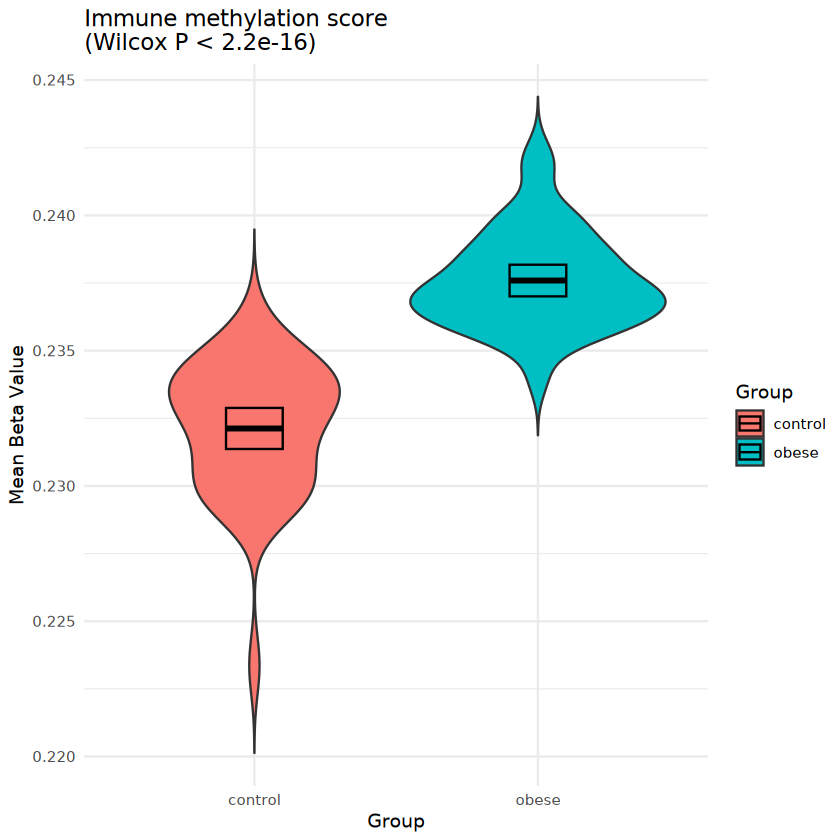

In [19]:
plot_immune

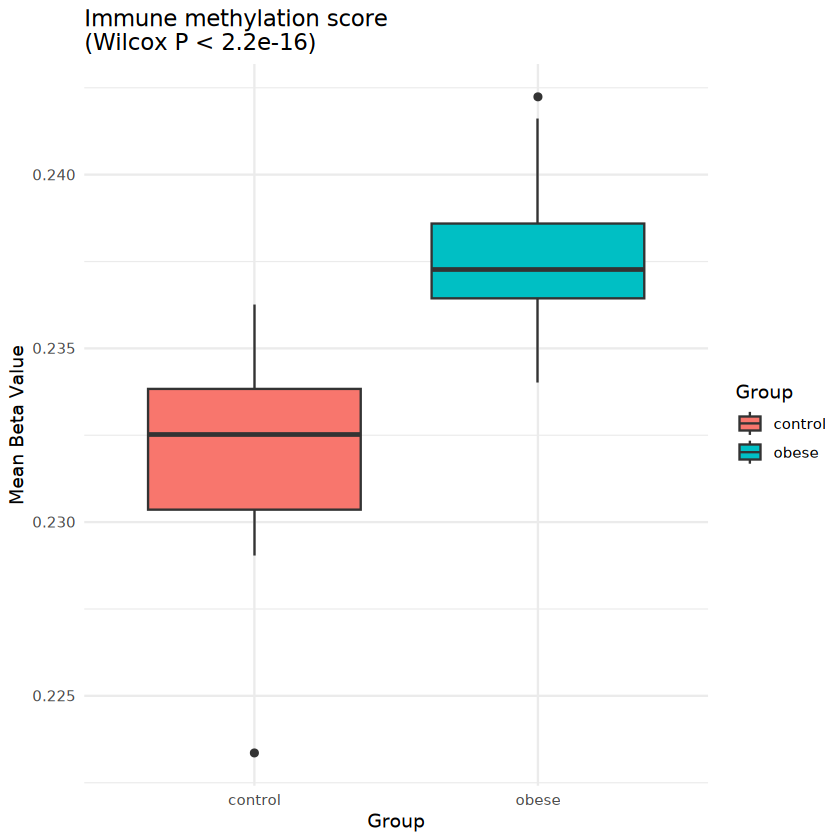

In [20]:
plot_immune2 =  ggplot(immune_cpg, aes(x = Group, y = Mean_beta, fill = Group)) +
  geom_boxplot() +
  labs(title = "Immune methylation score\n(Wilcox P < 2.2e-16)",
       x = "Group",
       y = "Mean Beta Value") +
  theme_minimal() 
plot_immune2

Picking joint bandwidth of 0.0594



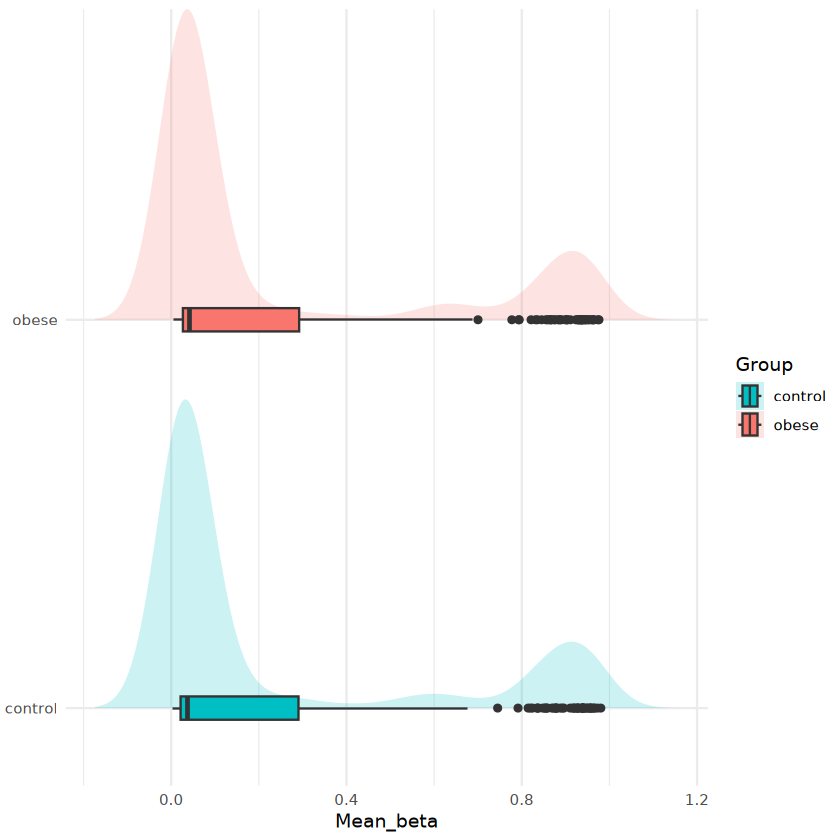

In [99]:
ggplot(immune_cpg, aes(x=Mean_beta, y=Group, fill=Group)) +
  scale_fill_manual(values = c("#00BFC4", "#F8766D"))+
  geom_density_ridges(aes(fill = Group), alpha=0.2, scale=0.8,color='transparent') +
  geom_boxplot(aes(fill = Group), width = 0.06)+theme_minimal()+scale_y_discrete(expand = c(0,0.2))+ 
  theme(plot.title = element_text(size=9),axis.title.y = element_blank())


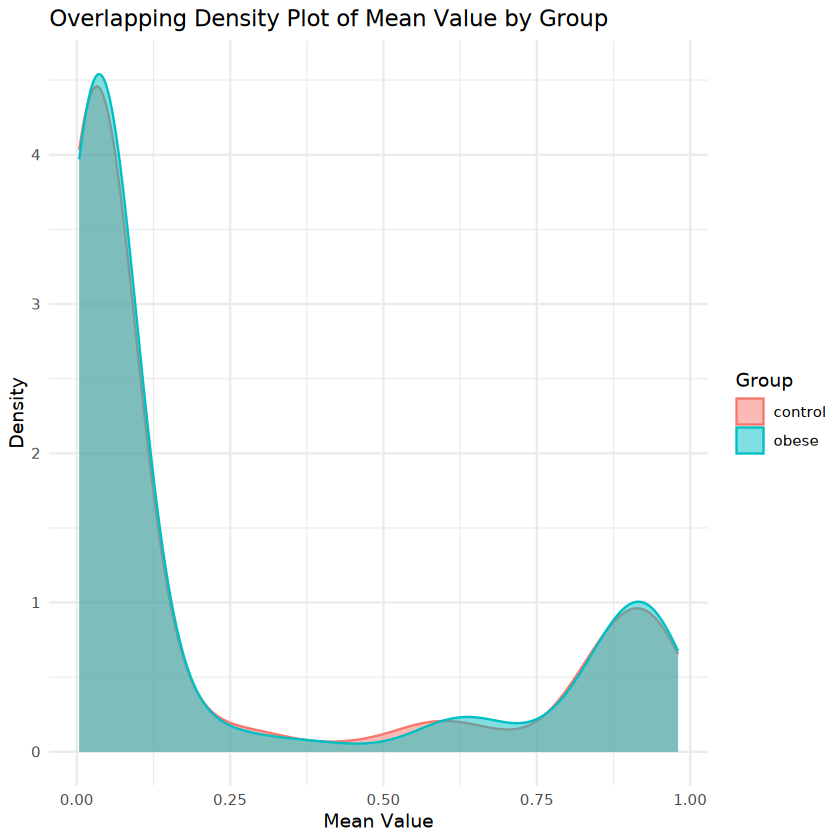

In [55]:
ggplot(immune_cpg, aes(x = Mean_beta, fill = Group, color = Group)) +
  geom_density(alpha = 0.5) +
  labs(title = "Overlapping Density Plot of Mean Value by Group",
       x = "Mean Value",
       y = "Density") +
  theme_minimal()

In [21]:
protein_pathways = c('path:hsa03020','path:hsa03022','path:hsa03040','path:hsa03010',
                     'path:hsa03013','path:hsa03015','path:hsa03008','path:hsa03060',
                     'path:hsa04141','path:hsa04130','path:hsa04120','path:hsa04122',
                     'path:hsa03050','path:hsa03018')

protein_pathways_synthesis = c('path:hsa03020','path:hsa03022','path:hsa03040','path:hsa03010',
                     'path:hsa03013','path:hsa03015','path:hsa03008','path:hsa03060',
                     'path:hsa04141','path:hsa04130')

In [22]:
protein_list = as.data.frame(unlist(missmethyl$idList[protein_pathways]))
colnames(protein_list) = c('gene')
protein_markers = unique(protein_list$gene)
CpG_anno_enz_promoter = CpG_anno_enz[CpG_anno_enz$UCSC_RefGene_Group%in%c('TSS200','TSS1500'),]
protein_marker_CpG = CpG_anno_enz_promoter[CpG_anno_enz_promoter$entrez_ids%in%protein_markers,]$Name
protein_marker_CpG_sig = protein_marker_CpG[protein_marker_CpG%in%rownames(sig_limma)]

In [23]:
cobre_beta_protein = cobre_beta[rownames(cobre_beta)%in%protein_marker_CpG_sig,]
cobre_beta_protein_control = cobre_beta_protein[,cobre_pd[cobre_pd$Sample_Group=='control',]$Sample_Name]
cobre_beta_protein_obese = cobre_beta_protein[,cobre_pd[cobre_pd$Sample_Group=='obese',]$Sample_Name]
control_protein_mean = colMeans(cobre_beta_protein_control)
obese_protein_mean = colMeans(cobre_beta_protein_obese)

In [24]:
control_protein_df = cbind(control_protein_mean,rep('control',length(control_protein_mean)))
colnames(control_protein_df) = c('Mean_beta','Group')
obese_protein_df = cbind(obese_protein_mean,rep('obese',length(obese_protein_mean)))
colnames(obese_protein_df) = c('Mean_beta','Group')
protein_cpg = as.data.frame(rbind(control_protein_df,obese_protein_df))
protein_cpg$Mean_beta = as.numeric(protein_cpg$Mean_beta)

In [26]:
wilcox.test(control_protein_mean,obese_protein_mean)


	Wilcoxon rank sum exact test

data:  control_protein_mean and obese_protein_mean
W = 86, p-value = 1.322e-12
alternative hypothesis: true location shift is not equal to 0


In [27]:
plot_protein = ggplot(protein_cpg, aes(x = Group, y = Mean_beta, fill = Group)) +
  geom_violin(trim = FALSE) +
  labs(title = "Protein methylation score\n(Wilcox P = 1.504e-12)",
       x = "Group",
       y = "Mean Beta Value") +
  theme_minimal() +
    stat_summary(fun.data = "mean_cl_boot", geom = "crossbar",
               colour = "black", width = 0.2)

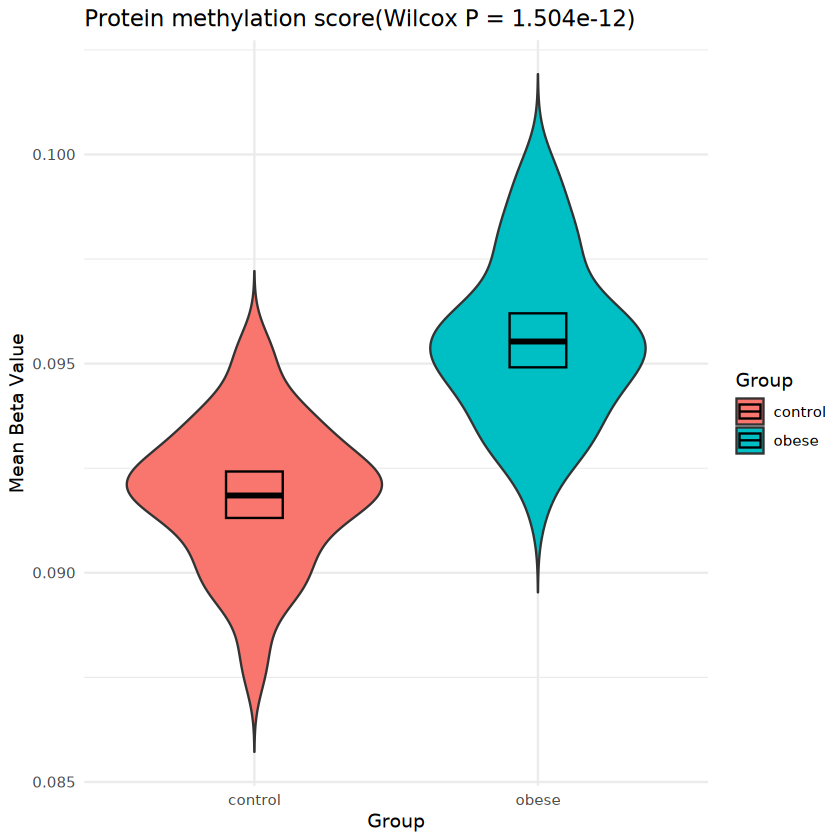

In [35]:
plot_protein

In [28]:
plot_protein2 = ggplot(protein_cpg, aes(x = Group, y = Mean_beta, fill = Group)) +
  geom_boxplot() +
  labs(title = "Protein methylation score\n(Wilcox P = 1.504e-12)",
       x = "Group",
       y = "Mean Beta Value") +
  theme_minimal() 

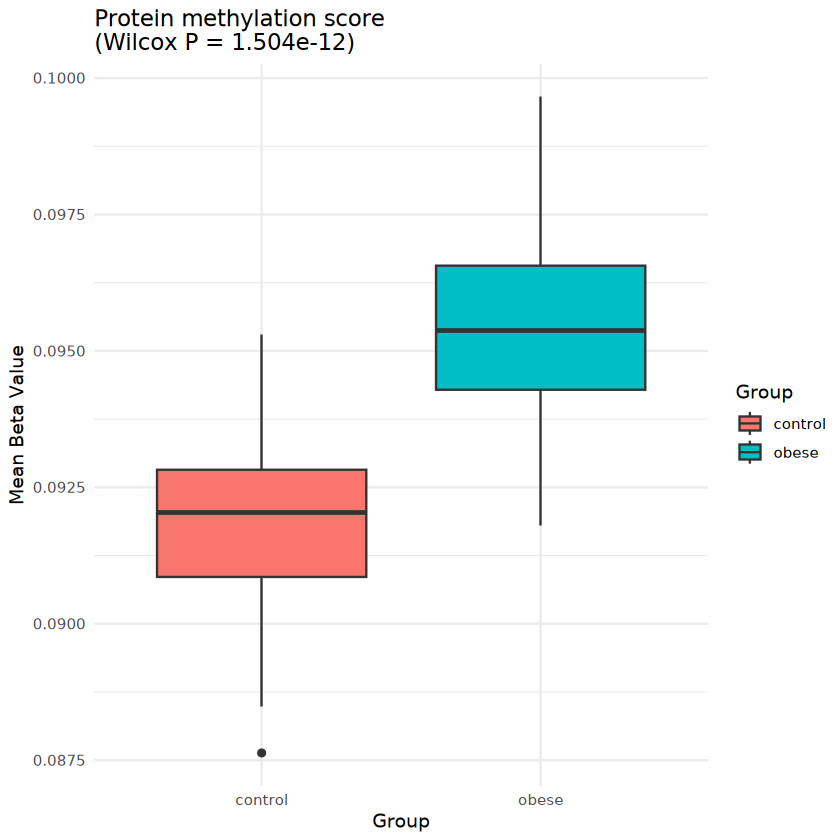

In [25]:
plot_protein2

In [29]:
png('plot_immune_box.png',width=4,height=3,unit='in',res=300)
plot_immune2
dev.off()
png('plot_protein_box.png',width=4,height=3,unit='in',res=300)
plot_protein2
dev.off()

png 
  2

png 
  2

In [44]:
png('plot_immune.png',width=4,height=3,unit='in',res=300)
plot_immune
dev.off()

png 
  2

In [45]:
png('plot_protein.png',width=4,height=3,unit='in',res=300)
plot_protein
dev.off()

png 
  2

In [58]:
load("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/RNA-seq analysis/RNA_normalized_log_counts.rdata",verbose=TRUE)

Loading objects:
  pd
  dds
  normalized_counts
  lognormalized_counts


In [60]:
load('annotation_entrez.rdata',verbose=TRUE)

Loading objects:
  anno
  gene_2_enz


In [146]:
immune_list = as.data.frame(unlist(missmethyl$idList[protein_pathways]))
colnames(immune_list) = c('gene')
immune_markers = unique(immune_list$gene)
CpG_anno_enz_promoter = CpG_anno_enz[CpG_anno_enz$UCSC_RefGene_Group%in%c('TSS200','TSS1500'),]
immune_marker_gene = unique(CpG_anno_enz_promoter[CpG_anno_enz_promoter$entrez_ids%in%immune_markers,]$UCSC_RefGene_Name)
gene_immune = lognormalized_counts[rownames(lognormalized_counts)%in%immune_marker_gene,]

In [147]:
dim(gene_immune)

[1] 888  47

In [148]:
cobre_beta_immune_control = gene_immune[,colnames(gene_immune)%in%cobre_pd[cobre_pd$Sample_Group=='control',]$Sample_Name]
cobre_beta_immune_obese = gene_immune[,colnames(gene_immune)%in%cobre_pd[cobre_pd$Sample_Group=='obese',]$Sample_Name]

In [149]:
t.test(control_immune_mean,obese_immune_mean)


	Welch Two Sample t-test

data:  control_immune_mean and obese_immune_mean
t = -0.36055, df = 35.539, p-value = 0.7206
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.07291053  0.05090826
sample estimates:
mean of x mean of y 
 7.044081  7.055082 


In [150]:
control_immune_mean = colMeans(cobre_beta_immune_control)
obese_immune_mean = colMeans(cobre_beta_immune_obese)
control_immune_df = cbind(control_immune_mean,rep('control',length(control_immune_mean)))
colnames(control_immune_df) = c('Mean_beta','Group')
obese_immune_df = cbind(obese_immune_mean,rep('obese',length(obese_immune_mean)))
colnames(obese_immune_df) = c('Mean_beta','Group')
immune_gene = as.data.frame(rbind(control_immune_df,obese_immune_df))
immune_gene$Mean_beta = as.numeric(immune_gene$Mean_beta)

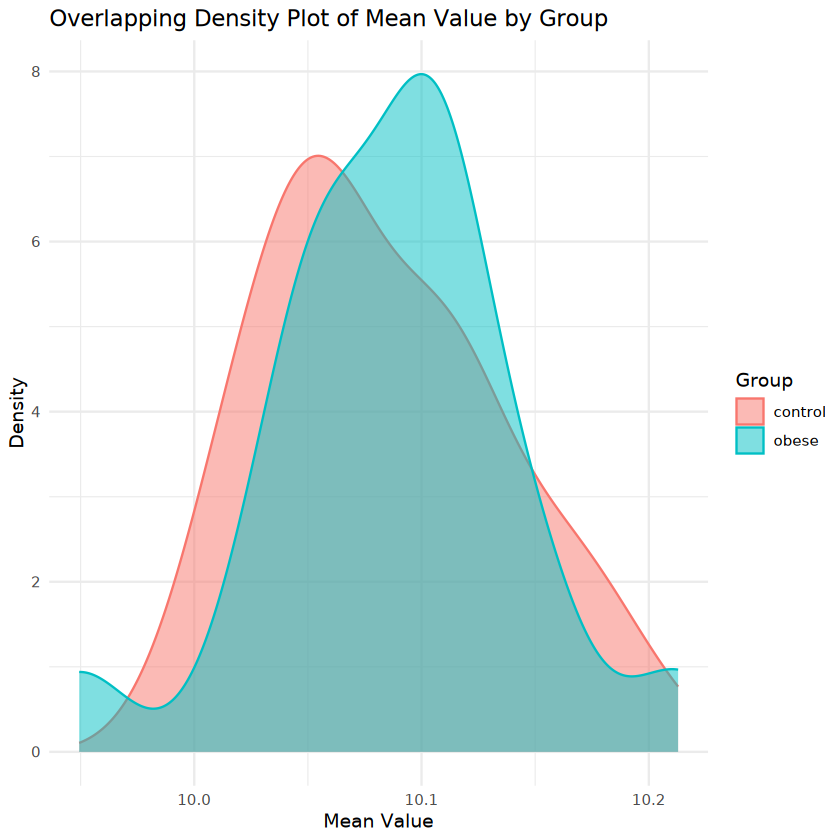

In [151]:
ggplot(immune_gene, aes(x = Mean_beta, fill = Group, color = Group)) +
  geom_density(alpha = 0.5) +
  labs(title = "Overlapping Density Plot of Mean Value by Group",
       x = "Mean Value",
       y = "Density") +
  theme_minimal()

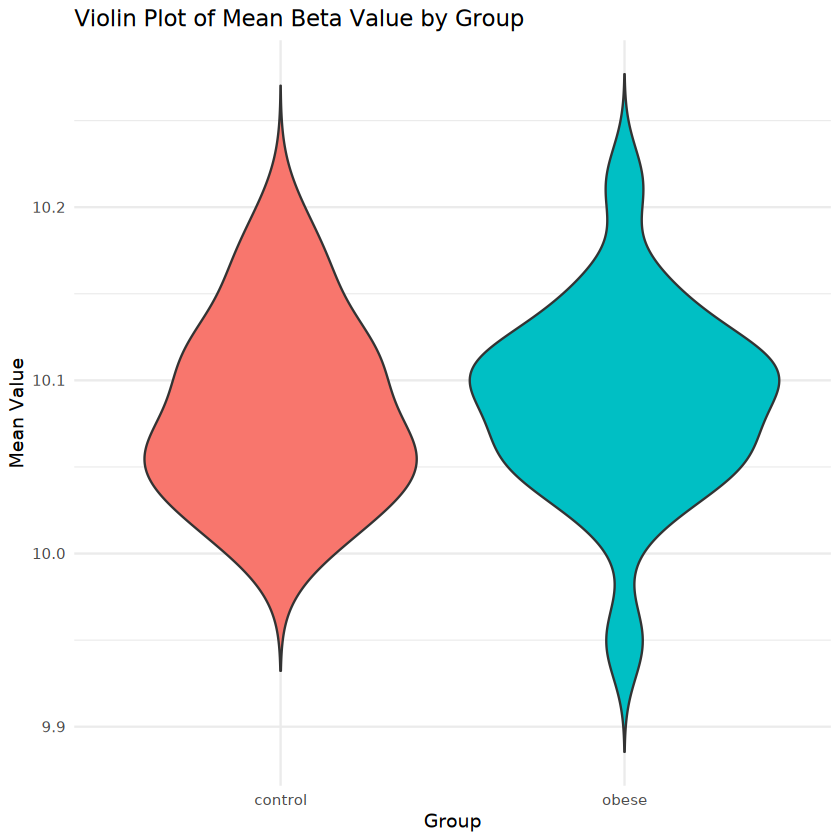

In [152]:
ggplot(immune_gene, aes(x = Group, y = Mean_beta, fill = Group)) +
  geom_violin(trim = FALSE) +
  labs(title = "Violin Plot of Mean Beta Value by Group",
       x = "Group",
       y = "Mean Value") +
  theme_minimal() +
  theme(legend.position = "none")